# Skenario 1: Cara Encoding Rating untuk Deteksi Inkonsistensi

**Pertanyaan Penelitian:** Dari tiga cara mengintegrasikan informasi rating ke dalam model, mana yang paling efektif untuk mendeteksi inkonsistensi?

| Variant | Cara Encoding Rating | Ilustrasi Input |
|---------|---------------------|------------------|
| A | Rating sebagai fitur numerik terpisah | teks review + [2] sebagai fitur tambahan di luar model |
| B | Rating di-concat ke representasi [CLS] | teks review → encode → [CLS] ⊕ rating_embedding |
| C | Rating sebagai token di awal teks | [RATING_2] teks review... → masuk bersama ke encoder |

## 1. Setup dan Instalasi

In [1]:
import subprocess, sys

packages = [
    'torch', 'transformers', 'scikit-learn',
    'pandas', 'numpy', 'tqdm', 'matplotlib', 'seaborn'
]

for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('Semua library berhasil diinstall.')

Installing torch...
Installing transformers...
Installing scikit-learn...
Installing pandas...
Installing numpy...
Installing tqdm...
Installing matplotlib...
Installing seaborn...
Semua library berhasil diinstall.


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, random

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Device: cuda


## 2. Load dan Persiapan Data

In [3]:
df = pd.read_csv('clean_reviews.csv')
print(f'Total data: {len(df):,}')
print(f'Kolom: {list(df.columns)}')
print(f'\nDistribusi label:')
print(df['label'].value_counts())
print(f'\nPersentase inkonsisten: {df["label"].mean()*100:.2f}%')
df.head(3)

Total data: 12,846
Kolom: ['app', 'app_id', 'username', 'rating', 'text', 'text_original', 'thumbs_up', 'date', 'reply', 'lang', 'word_count', 'text_sentiment', 'sentiment_confidence', 'label']

Distribusi label:
label
0    11802
1     1044
Name: count, dtype: int64

Persentase inkonsisten: 8.13%


,app,app_id,username,rating,text,text_original,thumbs_up,date,reply,lang,word_count,text_sentiment,sentiment_confidence,label
0,Gojek,com.gojek.app,Pengguna Google,5,sangat oke.. baik diperjalanan sangat membantu...,sangat oke... baik diperjalanan sangat membant...,0,2026-05-31 06:07:45,NaN,id,8,POSITIVE,0.9948,0
1,Gojek,com.gojek.app,Pengguna Google,5,baik & bagus servis nya,baik & bagus servis nya 👍👍,0,2026-05-31 05:22:59,NaN,id,5,POSITIVE,0.9951,0
2,Gojek,com.gojek.app,Pengguna Google,2,tiap hari langganan go-jek ke mana-mana tapi n...,tiap hari langganan Go-Jek ke mana-mana tapi n...,0,2026-05-31 05:05:10,"Mohon maaf atas kendalanya, Kak Ragil. Kesulit...",id,19,NEUTRAL,0.9886,0


### 2.1 Balancing Dataset dan Split

In [4]:
df_incon = df[df['label'] == 1]
df_con   = df[df['label'] == 0].sample(
    n=min(len(df_incon) * 3, len(df[df['label'] == 0])), random_state=SEED
)

df_balanced = pd.concat([df_incon, df_con]).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Dataset balanced: {len(df_balanced):,}')
print(df_balanced['label'].value_counts())

train_df, temp_df = train_test_split(
    df_balanced, test_size=0.3, random_state=SEED, stratify=df_balanced['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=SEED, stratify=temp_df['label']
)

print(f'\nTrain: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')

Dataset balanced: 4,176
label
0    3132
1    1044
Name: count, dtype: int64

Train: 2,923 | Val: 626 | Test: 627


## 3. Konfigurasi Model

In [5]:
MODEL_NAME  = 'indobenchmark/indobert-base-p1'
MAX_LEN     = 128
BATCH_SIZE  = 32
EPOCHS      = 5
LR          = 2e-5
NUM_CLASSES = 2

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer loaded: {MODEL_NAME}')
print(f'Vocab size: {tokenizer.vocab_size}')

Tokenizer loaded: indobenchmark/indobert-base-p1
Vocab size: 30521


## 4. Dataset Classes untuk Setiap Variant

In [6]:
class DatasetVariantA(Dataset):
    def __init__(self, texts, ratings, labels, tokenizer, max_len):
        self.texts    = texts
        self.ratings  = ratings
        self.labels   = labels
        self.tokenizer= tokenizer
        self.max_len  = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'rating':  torch.tensor(self.ratings[idx], dtype=torch.float),
            'label':   torch.tensor(self.labels[idx],  dtype=torch.long)
        }


class DatasetVariantB(Dataset):
    def __init__(self, texts, ratings, labels, tokenizer, max_len):
        self.texts    = texts
        self.ratings  = ratings
        self.labels   = labels
        self.tokenizer= tokenizer
        self.max_len  = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'rating':  torch.tensor(self.ratings[idx], dtype=torch.long),
            'label':   torch.tensor(self.labels[idx],  dtype=torch.long)
        }


class DatasetVariantC(Dataset):
    def __init__(self, texts, ratings, labels, tokenizer, max_len):
        self.texts  = [f'[RATING_{r}] {t}' for t, r in zip(texts, ratings)]
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len, padding='max_length',
            truncation=True, return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'label':   torch.tensor(self.labels[idx], dtype=torch.long)
        }

## 5. Model Architectures

In [7]:
class ModelVariantA(nn.Module):
    def __init__(self, model_name, num_classes=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + 1, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, rating):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        rating_norm = (rating / 5.0).unsqueeze(1)
        return self.classifier(torch.cat([cls, rating_norm], dim=1))


class ModelVariantB(nn.Module):
    def __init__(self, model_name, num_classes=2, rating_embed_dim=32):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.rating_embedding = nn.Embedding(6, rating_embed_dim)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size + rating_embed_dim, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask, rating):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        rating_embed = self.rating_embedding(rating)
        return self.classifier(torch.cat([cls, rating_embed], dim=1))


class ModelVariantC(nn.Module):
    def __init__(self, model_name, num_classes=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Linear(hidden_size, 256), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(256, num_classes)
        )

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]
        return self.classifier(cls)


print('Semua arsitektur model siap.')

Semua arsitektur model siap.


## 6. Training dan Evaluation Functions

In [8]:
def train_one_epoch(model, dataloader, optimizer, criterion, variant):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []

    for batch in tqdm(dataloader, desc='Training', leave=False):
        optimizer.zero_grad()
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        lbl  = batch['label'].to(DEVICE)

        if variant in ['A', 'B']:
            rating = batch['rating'].to(DEVICE)
            out = model(ids, mask, rating)
        else:
            out = model(ids, mask)

        loss = criterion(out, lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
        all_labels.extend(lbl.cpu().numpy())

    return (total_loss / len(dataloader),
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average='weighted'))


def evaluate(model, dataloader, criterion, variant):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            ids  = batch['input_ids'].to(DEVICE)
            mask = batch['attention_mask'].to(DEVICE)
            lbl  = batch['label'].to(DEVICE)

            if variant in ['A', 'B']:
                rating = batch['rating'].to(DEVICE)
                out = model(ids, mask, rating)
            else:
                out = model(ids, mask)

            loss = criterion(out, lbl)
            total_loss += loss.item()
            all_preds.extend(torch.argmax(out, dim=1).cpu().numpy())
            all_labels.extend(lbl.cpu().numpy())

    return (total_loss / len(dataloader),
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average='weighted'),
            all_preds, all_labels)

## 7. Training Pipeline untuk Ketiga Variant

In [9]:
def run_experiment(variant_name, model_class, dataset_class, train_df, val_df, test_df):
    print(f'\n{"="*60}')
    print(f'TRAINING VARIANT {variant_name}')
    print(f'{"="*60}')

    train_ds = dataset_class(train_df['text'].values, train_df['rating'].values, train_df['label'].values, tokenizer, MAX_LEN)
    val_ds   = dataset_class(val_df['text'].values,   val_df['rating'].values,   val_df['label'].values,   tokenizer, MAX_LEN)
    test_ds  = dataset_class(test_df['text'].values,  test_df['rating'].values,  test_df['label'].values,  tokenizer, MAX_LEN)

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)

    if variant_name == 'B':
        model = model_class(MODEL_NAME, NUM_CLASSES, rating_embed_dim=32).to(DEVICE)
    else:
        model = model_class(MODEL_NAME, NUM_CLASSES).to(DEVICE)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
    criterion = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'train_f1': [], 'val_f1': []}
    best_val_f1, best_model_state = 0, None

    for epoch in range(EPOCHS):
        print(f'\nEpoch {epoch+1}/{EPOCHS}')
        train_loss, train_acc, train_f1 = train_one_epoch(model, train_loader, optimizer, criterion, variant_name)
        val_loss,   val_acc,   val_f1, _, _ = evaluate(model, val_loader, criterion, variant_name)

        for k, v in zip(['train_loss','val_loss','train_acc','val_acc','train_f1','val_f1'],
                        [train_loss, val_loss, train_acc, val_acc, train_f1, val_f1]):
            history[k].append(v)

        print(f'  Train Loss: {train_loss:.4f} | Acc: {train_acc:.4f} | F1: {train_f1:.4f}')
        print(f'  Val   Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | F1: {val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1    = val_f1
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            print(f'  Best model updated (F1: {best_val_f1:.4f})')

    model.load_state_dict(best_model_state)
    test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(model, test_loader, criterion, variant_name)

    print(f'\n--- Test Results (Variant {variant_name}) ---')
    print(f'Test Loss: {test_loss:.4f} | Acc: {test_acc:.4f} | F1: {test_f1:.4f}')
    print('\nClassification Report:')
    print(classification_report(test_labels, test_preds, target_names=['Konsisten', 'Inkonsisten']))

    return {
        'variant':      variant_name,
        'history':      history,
        'test_acc':     test_acc,
        'test_f1':      test_f1,
        'test_preds':   test_preds,
        'test_labels':  test_labels,
        'model':        model
    }

## 8. Jalankan Eksperimen

In [10]:
results = {}
results['A'] = run_experiment('A', ModelVariantA, DatasetVariantA, train_df, val_df, test_df)


TRAINING VARIANT A

Epoch 1/5


  Train Loss: 0.4013 | Acc: 0.8235 | F1: 0.8130
  Val   Loss: 0.4268 | Acc: 0.8051 | F1: 0.8159
  Best model updated (F1: 0.8159)

Epoch 2/5


  Train Loss: 0.2586 | Acc: 0.8984 | F1: 0.8975
  Val   Loss: 0.3351 | Acc: 0.8610 | F1: 0.8647
  Best model updated (F1: 0.8647)

Epoch 3/5


  Train Loss: 0.1438 | Acc: 0.9449 | F1: 0.9449
  Val   Loss: 0.4265 | Acc: 0.8594 | F1: 0.8582

Epoch 4/5


  Train Loss: 0.0754 | Acc: 0.9750 | F1: 0.9751
  Val   Loss: 0.6732 | Acc: 0.8419 | F1: 0.8299

Epoch 5/5


  Train Loss: 0.0553 | Acc: 0.9843 | F1: 0.9843
  Val   Loss: 0.7844 | Acc: 0.8323 | F1: 0.8202



--- Test Results (Variant A) ---
Test Loss: 0.3413 | Acc: 0.8644 | F1: 0.8680

Classification Report:
              precision    recall  f1-score   support

   Konsisten       0.94      0.88      0.91       470
 Inkonsisten       0.69      0.82      0.75       157

    accuracy                           0.86       627
   macro avg       0.82      0.85      0.83       627
weighted avg       0.88      0.86      0.87       627



In [11]:
results['B'] = run_experiment('B', ModelVariantB, DatasetVariantB, train_df, val_df, test_df)


TRAINING VARIANT B

Epoch 1/5


  Train Loss: 0.4128 | Acc: 0.8235 | F1: 0.8113
  Val   Loss: 0.3347 | Acc: 0.8562 | F1: 0.8608
  Best model updated (F1: 0.8608)

Epoch 2/5


  Train Loss: 0.2397 | Acc: 0.9046 | F1: 0.9040
  Val   Loss: 0.3338 | Acc: 0.8626 | F1: 0.8535

Epoch 3/5


  Train Loss: 0.1298 | Acc: 0.9518 | F1: 0.9517
  Val   Loss: 0.4507 | Acc: 0.8562 | F1: 0.8516

Epoch 4/5


  Train Loss: 0.0757 | Acc: 0.9778 | F1: 0.9777
  Val   Loss: 0.7404 | Acc: 0.8419 | F1: 0.8275

Epoch 5/5


  Train Loss: 0.0689 | Acc: 0.9784 | F1: 0.9784
  Val   Loss: 0.6928 | Acc: 0.8355 | F1: 0.8295



--- Test Results (Variant B) ---
Test Loss: 0.3640 | Acc: 0.8293 | F1: 0.8364

Classification Report:
              precision    recall  f1-score   support

   Konsisten       0.93      0.83      0.88       470
 Inkonsisten       0.62      0.82      0.71       157

    accuracy                           0.83       627
   macro avg       0.78      0.83      0.79       627
weighted avg       0.85      0.83      0.84       627



In [12]:
results['C'] = run_experiment('C', ModelVariantC, DatasetVariantC, train_df, val_df, test_df)


TRAINING VARIANT C

Epoch 1/5


  Train Loss: 0.4271 | Acc: 0.8149 | F1: 0.7970
  Val   Loss: 0.5142 | Acc: 0.7812 | F1: 0.7934
  Best model updated (F1: 0.7934)

Epoch 2/5


  Train Loss: 0.2069 | Acc: 0.9193 | F1: 0.9180
  Val   Loss: 0.2509 | Acc: 0.9010 | F1: 0.8950
  Best model updated (F1: 0.8950)

Epoch 3/5


  Train Loss: 0.1061 | Acc: 0.9641 | F1: 0.9641
  Val   Loss: 0.2386 | Acc: 0.9201 | F1: 0.9176
  Best model updated (F1: 0.9176)

Epoch 4/5


  Train Loss: 0.0499 | Acc: 0.9867 | F1: 0.9867
  Val   Loss: 0.3772 | Acc: 0.9137 | F1: 0.9112

Epoch 5/5


  Train Loss: 0.0224 | Acc: 0.9938 | F1: 0.9938
  Val   Loss: 0.4453 | Acc: 0.9153 | F1: 0.9125



--- Test Results (Variant C) ---
Test Loss: 0.2060 | Acc: 0.9219 | F1: 0.9205

Classification Report:
              precision    recall  f1-score   support

   Konsisten       0.93      0.96      0.95       470
 Inkonsisten       0.88      0.80      0.84       157

    accuracy                           0.92       627
   macro avg       0.91      0.88      0.89       627
weighted avg       0.92      0.92      0.92       627



## 9. Perbandingan Hasil

In [13]:
print('=' * 60)
print('PERBANDINGAN HASIL KETIGA VARIANT')
print('=' * 60)

comparison = pd.DataFrame({
    'Variant':       ['A (Fitur Numerik)', 'B (Rating Embedding)', 'C (Token di Teks)'],
    'Test Accuracy': [results[v]['test_acc'] for v in ['A', 'B', 'C']],
    'Test F1-Score': [results[v]['test_f1']  for v in ['A', 'B', 'C']],
})
display(comparison)

best = comparison.loc[comparison['Test F1-Score'].idxmax()]
print(f'\nVariant terbaik: {best["Variant"]}')
print(f'  Accuracy: {best["Test Accuracy"]:.4f}')
print(f'  F1-Score: {best["Test F1-Score"]:.4f}')

PERBANDINGAN HASIL KETIGA VARIANT


,Variant,Test Accuracy,Test F1-Score
0,A (Fitur Numerik),0.864434,0.868007
1,B (Rating Embedding),0.829346,0.836373
2,C (Token di Teks),0.921850,0.920504



Variant terbaik: C (Token di Teks)
  Accuracy: 0.9219
  F1-Score: 0.9205


## 10. Visualisasi

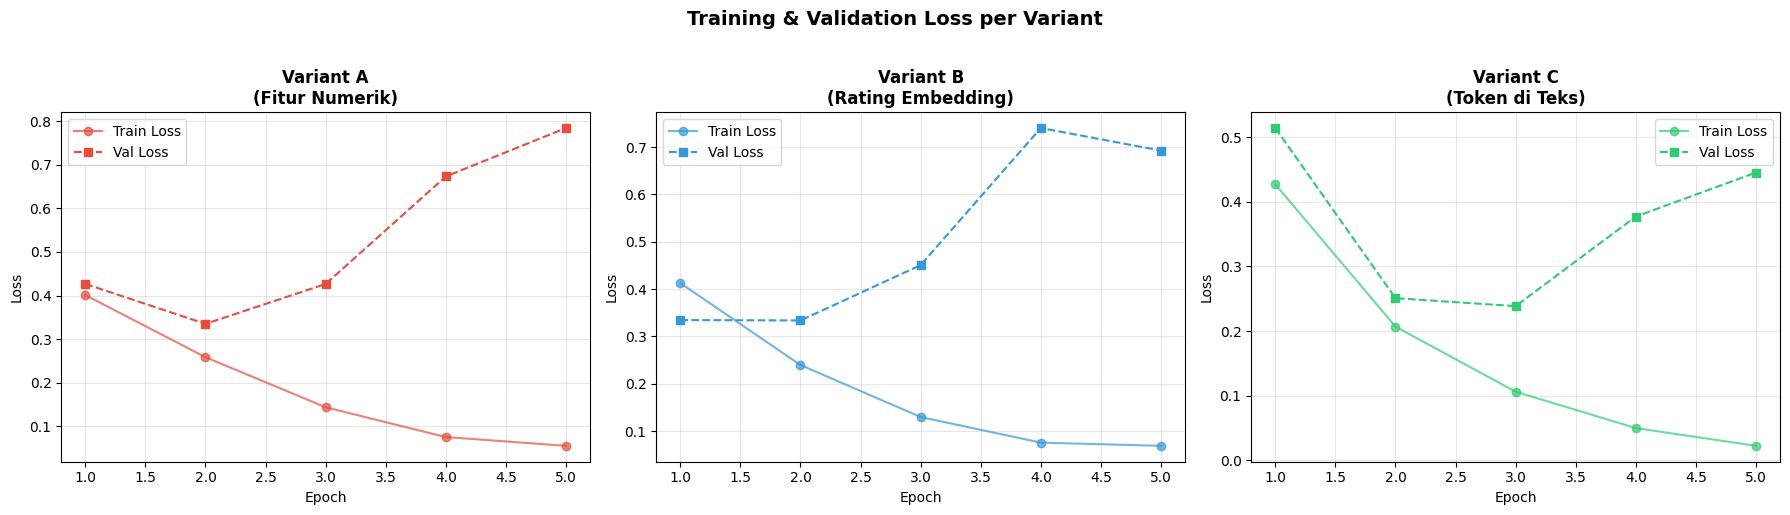

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = {'A': '#e74c3c', 'B': '#3498db', 'C': '#2ecc71'}
titles = {
    'A': 'Variant A\n(Fitur Numerik)',
    'B': 'Variant B\n(Rating Embedding)',
    'C': 'Variant C\n(Token di Teks)'
}

for i, v in enumerate(['A', 'B', 'C']):
    ax = axes[i]
    h  = results[v]['history']
    ep = range(1, EPOCHS + 1)
    ax.plot(ep, h['train_loss'], '-o', label='Train Loss', color=colors[v], alpha=0.7)
    ax.plot(ep, h['val_loss'],   '--s', label='Val Loss',   color=colors[v])
    ax.set_title(titles[v], fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training & Validation Loss per Variant', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

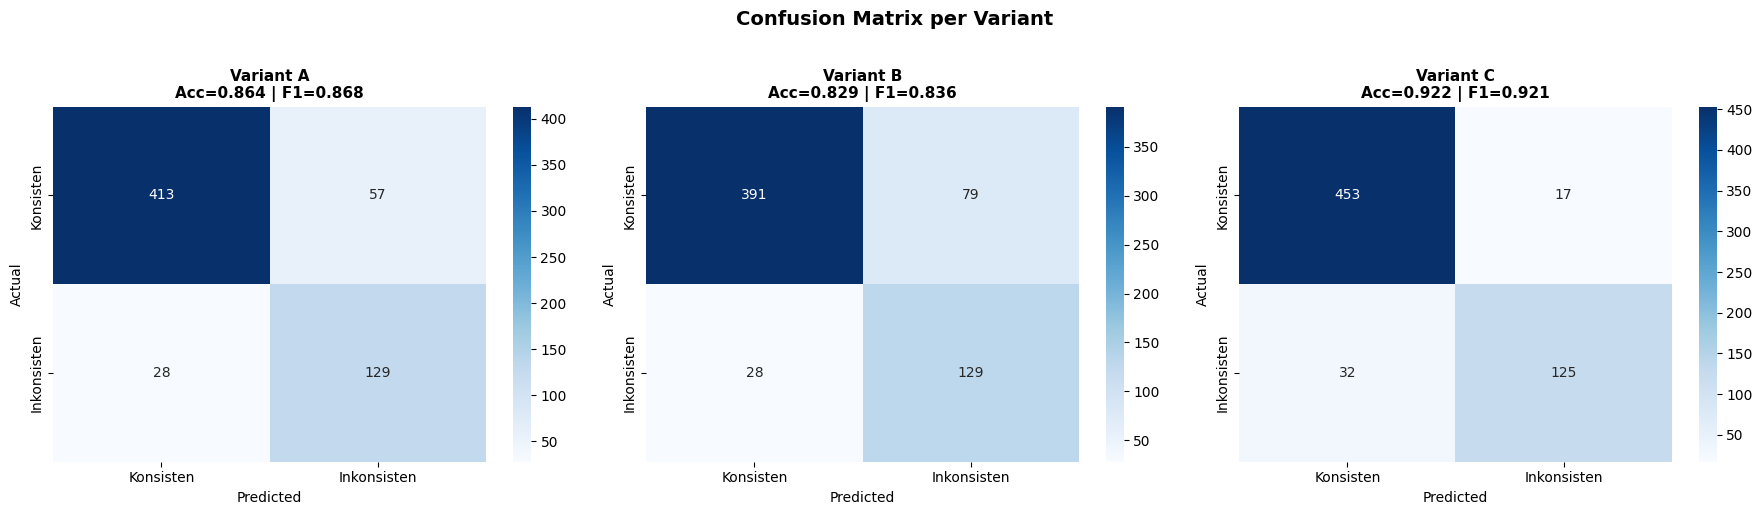

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, v in enumerate(['A', 'B', 'C']):
    ax = axes[i]
    cm = confusion_matrix(results[v]['test_labels'], results[v]['test_preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Konsisten', 'Inkonsisten'],
                yticklabels=['Konsisten', 'Inkonsisten'])
    ax.set_title(
        f'Variant {v}\nAcc={results[v]["test_acc"]:.3f} | F1={results[v]["test_f1"]:.3f}',
        fontsize=11, fontweight='bold'
    )
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrix per Variant', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

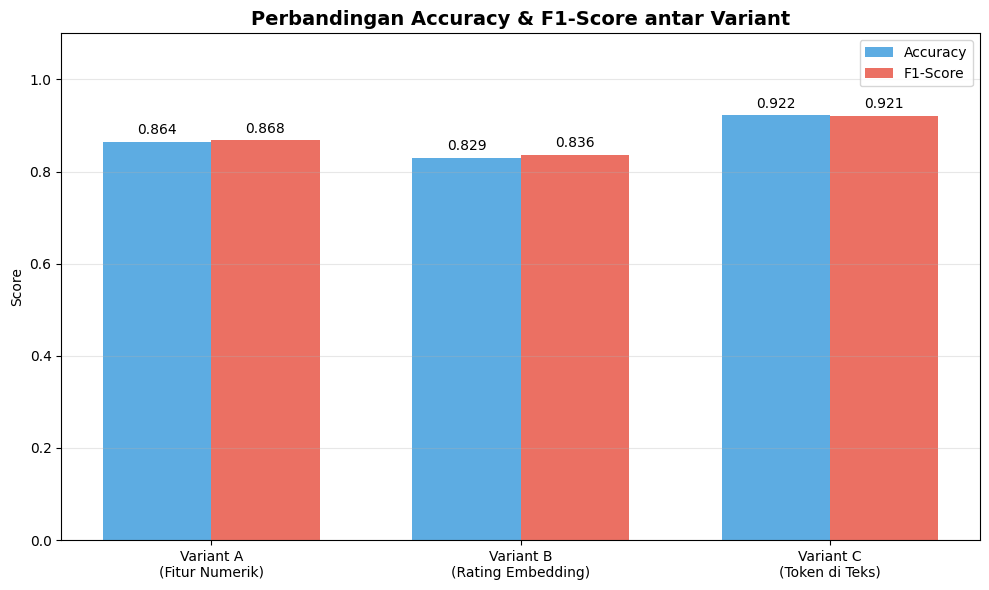

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

x      = np.arange(3)
width  = 0.35
labels_x = ['Variant A\n(Fitur Numerik)', 'Variant B\n(Rating Embedding)', 'Variant C\n(Token di Teks)']
acc_vals = [results[v]['test_acc'] for v in ['A', 'B', 'C']]
f1_vals  = [results[v]['test_f1']  for v in ['A', 'B', 'C']]

bars1 = ax.bar(x - width/2, acc_vals, width, label='Accuracy',  color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, f1_vals,  width, label='F1-Score',  color='#e74c3c', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(labels_x)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Accuracy & F1-Score antar Variant', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, axis='y', alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 11. Kesimpulan

Berdasarkan eksperimen Skenario 1, kita telah membandingkan tiga cara encoding rating:

- **Variant A**: Rating sebagai fitur numerik terpisah (di-concat setelah [CLS])
- **Variant B**: Rating di-embed lalu di-concat ke representasi [CLS]
- **Variant C**: Rating dimasukkan sebagai token teks `[RATING_X]` di awal input

Label inkonsistensi bersumber dari `clean_reviews.csv` yang dihasilkan oleh `preprocess.ipynb` menggunakan model pretrained `mdhugol/indonesia-bert-sentiment-classification` sebagai labeler.